# 04 - Cruce entre Radon y PyCEFR

In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("..").resolve()
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_pycefr = pd.read_csv(OUTPUT_DIR / "pycefr_constructs_global.csv")
df_radon = pd.read_csv(OUTPUT_DIR / "radon_functions_global.csv")

In [15]:
def cross_radon_pycefr(df_radon, df_pycefr):
    """Cruza cada función Radon con los constructos PyCEFR incluidos en su rango de líneas."""
    rows = []
    if df_radon.empty or df_pycefr.empty:
        return pd.DataFrame(rows)
    for _, fn in df_radon.iterrows():
        subset = df_pycefr[
            (df_pycefr["case"] == fn["case"]) &
            (df_pycefr["file_name"] == fn["file_name"]) &
            (df_pycefr["start_line"] >= fn["lineno"]) &
            (df_pycefr["end_line"] <= fn["endline"])
        ]
        level_counts = subset["level"].value_counts().to_dict() if not subset.empty else {}
        class_counts = subset["class"].value_counts().head(10).to_dict() if not subset.empty else {}
        max_level_num = subset["level_num"].max() if not subset.empty else np.nan
        rows.append({
            "case": fn["case"],
            "file": fn["file"],
            "file_name": fn["file_name"],
            "function": fn["name"],
            "parent": fn.get("parent"),
            "lineno": fn["lineno"],
            "endline": fn["endline"],
            "complexity": fn["complexity"],
            "radon_grade": fn["radon_grade"],
            "radon_grade_num": fn["radon_grade_num"],
            "n_pycefr_constructs": len(subset),
            "n_pycefr_classes": subset["class"].nunique() if not subset.empty else 0,
            "max_level_num": max_level_num,
            "max_level": LEVEL_ORDER_INV.get(int(max_level_num)) if pd.notna(max_level_num) else None,
            "mean_level_num": subset["level_num"].mean() if not subset.empty else np.nan,
            "level_counts": json.dumps(level_counts, ensure_ascii=False),
            "top_classes": json.dumps(class_counts, ensure_ascii=False),
        })
    return pd.DataFrame(rows)

def label_interesting_cases(cross):
    df = cross.copy()
    if df.empty:
        df["case_type"] = []
        return df
    conditions = []
    for _, row in df.iterrows():
        labels = []
        if row.get("radon_grade_num", 0) >= 2 and row.get("max_level_num", 0) <= 2:
            labels.append("Radon alto / PyCEFR bajo")
        if row.get("radon_grade_num", 0) <= 1 and row.get("max_level_num", 0) >= 5:
            labels.append("PyCEFR alto / Radon bajo")
        if row.get("radon_grade_num", 0) >= 2 and row.get("max_level_num", 0) >= 4:
            labels.append("Coincidencia en dificultad alta")
        if row.get("n_pycefr_constructs", 0) >= 25 and row.get("max_level_num", 0) <= 2:
            labels.append("Muchos constructos simples acumulados")
        if not labels:
            labels.append("Sin patrón destacado")
        conditions.append("; ".join(labels))
    df["case_type"] = conditions
    return df

In [16]:

# Compatibilidad por si existe una tabla antigua con la columna original de Radon
if "radon_grade" not in df_radon.columns and "rank" in df_radon.columns:
    df_radon["radon_grade"] = df_radon["rank"]
if "radon_grade_num" not in df_radon.columns and "rank_num" in df_radon.columns:
    df_radon["radon_grade_num"] = df_radon["rank_num"]

cross = cross_radon_pycefr(df_radon, df_pycefr)
cross.head()


,case,file,file_name,function,parent,lineno,endline,complexity,radon_grade,radon_grade_num,n_pycefr_constructs,n_pycefr_classes,max_level_num,max_level,mean_level_num,level_counts,top_classes
0,30-Days-Of-Python,/home/juan/Documents/Analisis-CC-PyCEFR/30-Day...,mymodule.py,generate_full_name,NaN,1,4,1,A,1,8,4,1.0,A1,1.0,"{""A1"": 8}","{""Simple Assignment"": 2, ""Assigment with sum (..."
1,30-Days-Of-Python,/home/juan/Documents/Analisis-CC-PyCEFR/30-Day...,mymodule.py,sum_two_nums,NaN,7,8,1,A,1,4,3,1.0,A1,1.0,"{""A1"": 4}","{""Return"": 2, ""Simple Assignment"": 1, ""Functio..."
2,30-Days-Of-Python,/home/juan/Documents/Analisis-CC-PyCEFR/30-Day...,mymodule.py,generate_full_name,NaN,1,4,1,A,1,8,4,1.0,A1,1.0,"{""A1"": 8}","{""Simple Assignment"": 2, ""Assigment with sum (..."
3,30-Days-Of-Python,/home/juan/Documents/Analisis-CC-PyCEFR/30-Day...,mymodule.py,sum_two_nums,NaN,6,7,1,A,1,2,2,1.0,A1,1.0,"{""A1"": 2}","{""Function with Simple argument"": 1, ""Return"": 1}"
4,30-Days-Of-Python,/home/juan/Documents/Analisis-CC-PyCEFR/30-Day...,arithmetic.py,add_numbers,NaN,1,5,2,A,1,5,5,3.0,B1,1.6,"{""A1"": 3, ""A2"": 1, ""B1"": 1}","{""Simple Assignment"": 1, ""Simplified increment..."


In [18]:
print(cross.shape)
cross[["case", "file_name", "function", "complexity", "radon_grade", "n_pycefr_constructs", "max_level"]].head(20)

(1961, 17)


,case,file_name,function,complexity,radon_grade,n_pycefr_constructs,max_level
0,30-Days-Of-Python,mymodule.py,generate_full_name,1,A,8,A1
1,30-Days-Of-Python,mymodule.py,sum_two_nums,1,A,4,A1
2,30-Days-Of-Python,mymodule.py,generate_full_name,1,A,8,A1
3,30-Days-Of-Python,mymodule.py,sum_two_nums,1,A,2,A1
4,30-Days-Of-Python,arithmetic.py,add_numbers,2,A,5,B1
5,30-Days-Of-Python,arithmetic.py,subtract,1,A,2,A1
6,30-Days-Of-Python,arithmetic.py,multiple,1,A,2,A1
7,30-Days-Of-Python,arithmetic.py,division,1,A,2,A1
8,30-Days-Of-Python,arithmetic.py,remainder,1,A,2,A1
9,30-Days-Of-Python,arithmetic.py,power,1,A,2,A1


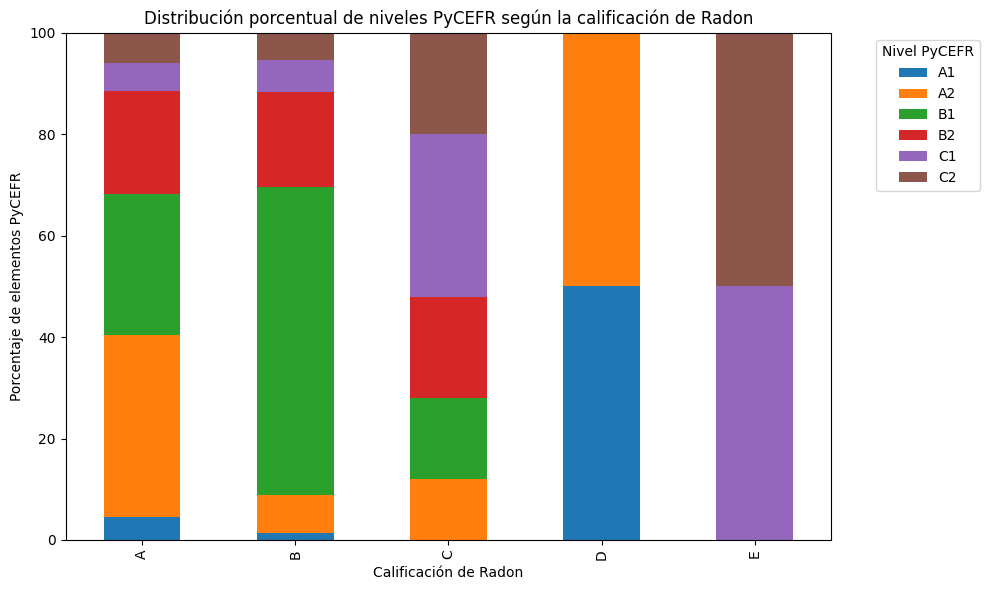

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar matriz de cruce ya generada
df = pd.read_csv(OUTPUT_DIR / "04_tabla_cruce_radon_pycefr.csv")

# Orden de calificaciones y niveles
orden_radon = ["A", "B", "C", "D", "E", "F"]
niveles_pycefr = ["A1", "A2", "B1", "B2", "C1", "C2"]

# Asegurar orden y rellenar posibles calificaciones ausentes
df = (
    df.set_index("radon_grade")
      .reindex(orden_radon, fill_value=0)
)

# Quedarse solo con niveles PyCEFR
tabla = df[niveles_pycefr]

# Convertir a porcentaje por fila
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

# Quitar filas sin datos, por ejemplo F si no aparece
tabla_pct = tabla_pct.loc[tabla_pct.sum(axis=1) > 0]

# Figura
ax = tabla_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribución porcentual de niveles PyCEFR según la calificación de Radon")
plt.xlabel("Calificación de Radon")
plt.ylabel("Porcentaje de elementos PyCEFR")
plt.legend(title="Nivel PyCEFR", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "04_distribucion_porcentual_pycefr_por_radon.png", dpi=300, bbox_inches="tight")
plt.show()

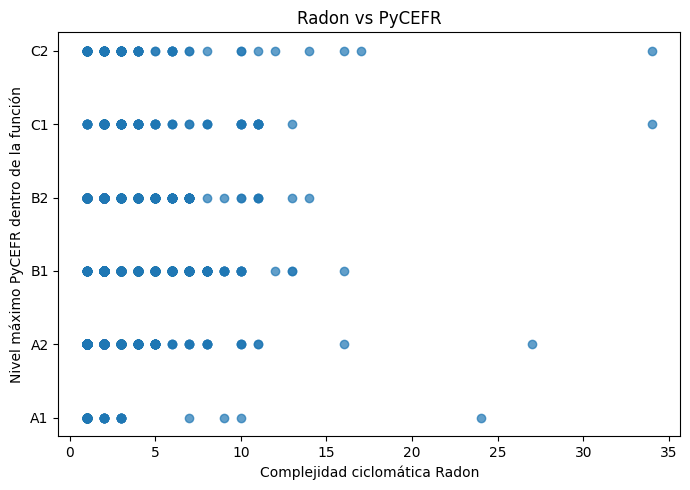

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(cross["complexity"], cross["max_level_num"], alpha=0.7)
plt.title("Radon vs PyCEFR")
plt.xlabel("Complejidad ciclomática Radon")
plt.ylabel("Nivel máximo PyCEFR dentro de la función")
plt.yticks(list(LEVEL_ORDER_INV.keys()), list(LEVEL_ORDER_INV.values()))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_radon_vs_pycefr_scatter.png", dpi=150)
plt.show()

In [20]:
concordance = pd.crosstab(cross["radon_grade"], cross["max_level"])
concordance

max_level,A1,A2,B1,B2,C1,C2
radon_grade,,,,,,
A,78,608,470,343,96,100
B,3,15,124,38,13,11
C,0,3,4,5,8,5
D,1,1,0,0,0,0
E,0,0,0,0,1,1


In [13]:
cross.to_csv(OUTPUT_DIR / "04_radon_pycefr_cross_global.csv", index=False)
concordance.to_csv(OUTPUT_DIR / "04_tabla_cruce_radon_pycefr.csv")